 HOUSE PRICE PREDICTION PROJECT

In [1]:
#Step 1: Data set loading
import pandas as pd
df=pd.read_csv('/content/Bengaluru_House_Data.csv')
print(df.head())


FileNotFoundError: [Errno 2] No such file or directory: '/content/Bengaluru_House_Data.csv'

In [ ]:
#Step2: Data Cleaning and processing
import pandas as pd
print(df.shape) #shape of dataset
print(df.info)
print(df.columns)#columns of data set
print(df.dtypes)
print(df.isnull().sum())#removing null values
df.dropna(inplace=True)
print(df.isnull().sum())
print(df.describe())

df.drop_duplicates(inplace=True)#removing duplicates
print(df.duplicated().sum())


df.drop(['area_type','society','availability',],axis=1,inplace=True)#removing unessecary columns

df['bhk'] = df['size'].str.split().str[0].astype(int)
df.drop('size', axis=1, inplace=True)

df = df[df['total_sqft'].str.contains('-') == False]#removing the total_sqt values which contains - b/w values (it will reduce model performance)
df['total_sqft'] = pd.to_numeric(df['total_sqft'], errors='coerce')
df.dropna(inplace=True)

df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']#creating new column price per sqft




(13320, 9)
<bound method DataFrame.info of                   area_type   availability                  location  \
0      Super built-up  Area         19-Dec  Electronic City Phase II   
1                Plot  Area  Ready To Move          Chikka Tirupathi   
2            Built-up  Area  Ready To Move               Uttarahalli   
3      Super built-up  Area  Ready To Move        Lingadheeranahalli   
4      Super built-up  Area  Ready To Move                  Kothanur   
...                     ...            ...                       ...   
13315        Built-up  Area  Ready To Move                Whitefield   
13316  Super built-up  Area  Ready To Move             Richards Town   
13317        Built-up  Area  Ready To Move     Raja Rajeshwari Nagar   
13318  Super built-up  Area         18-Jun           Padmanabhanagar   
13319  Super built-up  Area  Ready To Move              Doddathoguru   

            size  society total_sqft  bath  balcony   price  
0          2 BHK  Coomee      

In [ ]:
#Step3: Feature Selection
import pandas as pd
X=df.drop('price',axis=1) #features
y=df['price']#columns
X = pd.get_dummies(X, drop_first=True)#handling categorical data

In [ ]:
#Step4: train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#Step5: Scaling
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

Using Linear Regression Model

In [ ]:
#Step6: Model Selection
from sklearn.linear_model import LinearRegression

model =LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
#Step7: Model prediction
y_pred=model.predict(X_test)

In [ ]:
#Step8: Model Evaluation
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_pred,y_test)
r2=r2_score(y_pred,y_test)
print("mse:",mse)
print("r2:",r2)

mse: 2641.1526781809002
r2: 0.6661279012220792


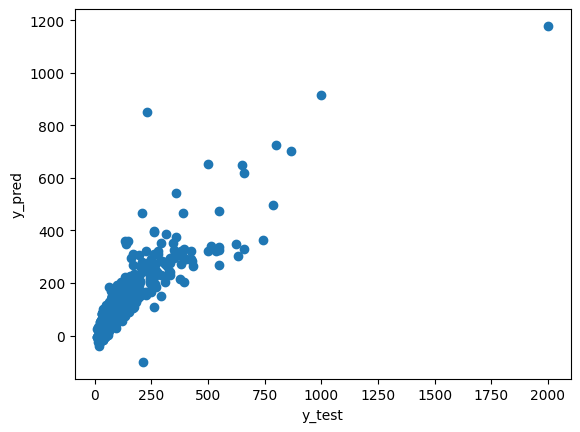

In [ ]:
#Step9: Visualization
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.show()